# Task 3

# Эмпирическое распределение и p-value
Цель: промоделировать вычисление порога для заданного уровня значимости.
Задачи:
1. Напишите генератор случайных последовательностей длины L = 9 с частотами генома человека
(A/T : 0.295, G/C : 0.205).
2. Сгенерируйте 100 000 таких "фоновых"последовательностей.
3. Посчитайте скор по вашей PWM для каждой из 100 000 последовательностей.
4. Постройте гистограмму распределения скоров (используя matplotlib.pyplot.hist).
5. Напишите функцию get_pvalue(score), которая возвращает долю фоновых скоров ≥заданного
score.
6. Найдите, какой порог (threshold) нужно установить, чтобы p-value ≈10−4


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def random_sequence(length, probs=None):
    """
    Генерирует случайную последовательность ДНК заданной длины.
    probs: dict {'A': pA, 'T': pT, 'G': pG, 'C': pC}
    """
    if probs is None:
        probs = {'A': 0.295, 'T': 0.295, 'G': 0.205, 'C': 0.205}
    
    nucleotides = list(probs.keys())
    probabilities = list(probs.values())
    
    seq = np.random.choice(nucleotides, size=length, p=probabilities)
    return ''.join(seq)

In [3]:
L = 9
n_seqs = 100000

background_seqs = [random_sequence(L) for _ in range(n_seqs)]

In [4]:
pwm = np.array([
    [0.5, -1.0, -1.0, 0.5],
    [0.8, -0.5, -0.5, 0.8],
    [1.0, -2.0, -2.0, 1.0],
    [-1.0, 1.0, 1.0, -1.0],
    [-0.5, 0.5, 0.5, -0.5],
    [0.3, 0.3, -1.0, -1.0],
    [0.7, -1.5, -1.5, 0.7],
    [-1.0, 1.2, 1.2, -1.0],
    [0.6, -0.8, -0.8, 0.6]
])

nuc_order = ['A', 'C', 'G', 'T']

def score_sequence(seq, pwm, nuc_order):
    score = 0
    for i, nuc in enumerate(seq):
        nuc_index = nuc_order.index(nuc)
        score += pwm[i, nuc_index]
    return score

scores = [score_sequence(seq, pwm, nuc_order) for seq in background_seqs]
scores = np.array(scores)

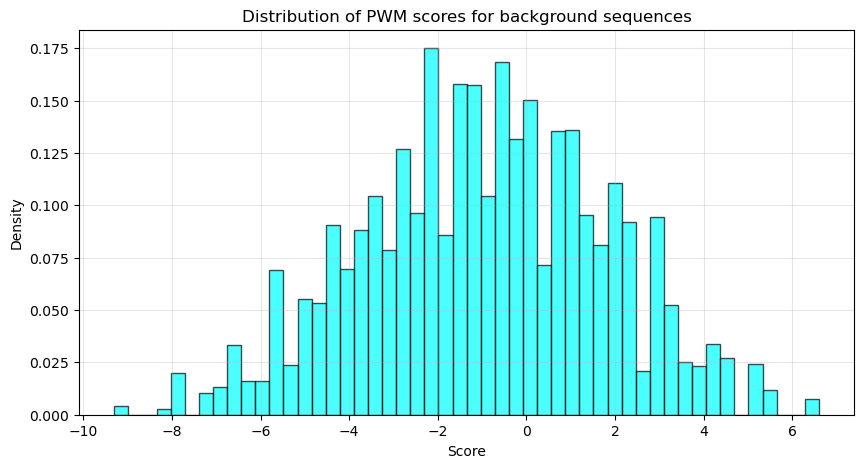

In [6]:
plt.figure(figsize=(10,5))
plt.hist(scores, bins=50, density=True, alpha=0.7, color='cyan', edgecolor='black')
plt.xlabel('Score')
plt.ylabel('Density')
plt.title('Distribution of PWM scores for background sequences')
plt.grid(alpha=0.3)
plt.show()

In [7]:
def get_pvalue(score, scores):
    """
    Возвращает долю фоновых скоров ≥ заданного score.
    """
    return np.mean(scores >= score)

In [8]:
target_pvalue = 1e-4

sorted_scores = np.sort(scores)[::-1]

idx = int(target_pvalue * len(sorted_scores))

threshold = sorted_scores[idx]

print(f"Порог для p-value ≈ {target_pvalue:.0e}: {threshold:.3f}")

Порог для p-value ≈ 1e-04: 6.600


In [9]:
pvalue_at_threshold = get_pvalue(threshold, scores)
print(f"Реальное p-value при пороге {threshold:.3f}: {pvalue_at_threshold:.5f}")

Реальное p-value при пороге 6.600: 0.00238
